# Marketing Campaign Performance Analysis

## Project Overview

This project analyzes digital marketing campaign performance using Python and Pandas.

The analysis focuses on campaign, platform, country, and time-based performance using key marketing KPIs such as CTR, CPC, Conversion Rate, CPA, CPM, and ROAS.

The goal is to identify performance patterns, compare marketing channels and markets, and generate data-driven business insights and recommendations.

> Note: The dataset is simulated and is used for analytical and portfolio purposes.

## Business Questions

This analysis aims to answer the following business questions:

1. Which marketing platforms generate the best performance?
2. Which campaigns deliver the highest ROAS and conversion efficiency?
3. Which countries or markets perform better?
4. How does marketing performance change over time?
5. Which periods show stronger revenue and ROAS?
6. Where are there opportunities to improve marketing efficiency?
7. How can the findings support better budget allocation and campaign optimization?

## Dataset

The dataset contains digital marketing campaign performance data across multiple platforms, countries, campaigns, and time periods.

### Dataset Includes

- Campaign and ad information
- Marketing platform and placement
- Country and market tier
- Funnel stage and campaign objective
- Impressions, reach, clicks, and spend
- Conversions and revenue
- Video views
- Date and time-related features

### Dataset Source

The dataset is a simulated digital marketing dataset used for analytical and portfolio purposes.

## Data Preparation

The dataset was reviewed and prepared before analysis.

The preparation steps included:

- Loading the dataset
- Checking the dataset structure and data types
- Checking for missing values and duplicates
- Converting date columns to the correct format
- Creating time-based features where needed
- Verifying numeric columns for analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

dm= pd.read_csv("/kaggle/input/datasets/abedmiah/digital-marketing-performance-dataset/digital_marketing_dataset_30k.csv")

dm.head()

,date,year,month,month_name,week,day_of_week,post_hour,season,is_holiday,is_holiday (text),...,ad_id,ad_name,spend,impressions,reach,frequency,clicks,conversions,revenue,video_views
0,08/04/2023,2023,4,Apr,14,Sat,7,Spring,0,No,...,AD8747890,In-Feed_V1,871.17,172632,77865,2.22,1440,0,0.00,54610
1,28/04/2025,2025,4,Apr,18,Mon,12,Spring,0,No,...,AD2884130,Feed_V9,362.55,30111,15083,2.00,283,0,0.00,8086
2,18/12/2024,2024,12,Dec,51,Wed,10,Winter,0,No,...,AD5656772,Display_V7,362.09,111125,56453,1.97,1238,7,671.74,0
3,26/04/2024,2024,4,Apr,17,Fri,20,Spring,0,No,...,AD3443678,Stories_V2,54.45,10844,4736,2.29,83,0,0.00,0
4,19/04/2024,2024,4,Apr,16,Fri,22,Spring,0,No,...,AD8461978,Reels_V8,56.18,6423,3010,2.13,59,0,0.00,1160


In [2]:
dm.shape
dm.info()
dm.describe()
dm.columns
dm.isnull().sum()
dm.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 35 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               30000 non-null  object 
 1   year               30000 non-null  int64  
 2   month              30000 non-null  int64  
 3   month_name         30000 non-null  object 
 4   week               30000 non-null  int64  
 5   day_of_week        30000 non-null  object 
 6   post_hour          30000 non-null  int64  
 7   season             30000 non-null  object 
 8   is_holiday         30000 non-null  int64  
 9   is_holiday (text)  30000 non-null  object 
 10  is_weekend         30000 non-null  int64  
 11  is_weekend (text)  30000 non-null  object 
 12  country            30000 non-null  object 
 13  market_tier        30000 non-null  object 
 14  account            30000 non-null  object 
 15  account_type       30000 non-null  object 
 16  platform           300

np.int64(0)

In [3]:
dm['Date'] = pd.to_datetime(dm['date'],
                format='%d/%m/%Y'           
                           )

dm['Date'].dtype

dtype('<M8[ns]')

In [4]:
dm['Year'] = dm['Date'].dt.year
dm['Month'] = dm['Date'].dt.month

dm[['Date', 'Year', 'Month']].head()

,Date,Year,Month
0,2023-04-08,2023,4
1,2025-04-28,2025,4
2,2024-12-18,2024,12
3,2024-04-26,2024,4
4,2024-04-19,2024,4


In [5]:
dm.nunique().sort_values()

is_weekend (text)        2
is_weekend               2
is_holiday (text)        2
account_type             2
is_holiday               2
year                     3
market_tier              3
funnel_stage             3
Year                     3
season                   4
objective                6
platform                 6
day_of_week              7
account                  7
theme                    8
placement               11
month_name              12
country                 12
Month                   12
month                   12
post_hour               24
week                    52
ad_name                 99
frequency              210
conversions            405
Date                  1096
date                  1096
ad_group_name         4041
clicks                4279
video_views           8607
revenue               8744
campaign_name        19192
reach                21739
spend                24027
impressions          25004
campaign_id          25548
ad_group_id          29496
a

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand the overall distribution, patterns, and relationships within the marketing data before evaluating campaign performance.

In [6]:
dm["CTR"] = (dm["clicks"]/ dm['impressions']) *100
dm["CPC"] = dm["spend"] / dm["clicks"]
dm["Conversion_rate"] = (dm["conversions"]/dm["clicks"])*100
dm["CPA"] = dm["spend"]/dm["conversions"]
dm["CPM"] = (dm["spend"]/dm["impressions"])*1000
dm["ROAS"] = dm["revenue"]/ dm["spend"]

dm[['CTR','CPC', 'Conversion_rate', 'CPA', 'CPM', 'ROAS']].head(5)


,CTR,CPC,Conversion_rate,CPA,CPM,ROAS
0,0.834144,0.604979,0.000000,inf,5.046399,0.000000
1,0.939856,1.281095,0.000000,inf,12.040450,0.000000
2,1.114061,0.292480,0.565428,51.727143,3.258403,1.855174
3,0.765400,0.656024,0.000000,inf,5.021210,0.000000
4,0.918574,0.952203,0.000000,inf,8.746692,0.000000


In [7]:
total_impressions = dm['impressions'].sum()
total_clicks = dm['clicks'].sum()
total_spend = dm['spend'].sum()
total_conversions = dm['conversions'].sum()
total_revenue = dm['revenue'].sum()

overall_kpis = pd.DataFrame({
    'metric': ['impressions', 'clicks', 'spend', 'conversions', 'revenue'],
    'value': [
        total_impressions,
        total_clicks,
        total_spend,
        total_conversions,
        total_revenue
    ]
})

overall_kpis

,metric,value
0,impressions,1.701763e+09
1,clicks,2.561714e+07
2,spend,1.263641e+07
3,conversions,3.227980e+05
4,revenue,1.427135e+07


In [8]:
overall_kpis = {
    'CTR': total_clicks / total_impressions * 100,
    'CPC': total_spend / total_clicks,
    'Conversion_rate': total_conversions / total_clicks * 100,
    'CPA': total_spend / total_conversions,
    'CPM': total_spend / total_impressions * 1000,
    'ROAS': total_revenue / total_spend
}

overall_kpis

{'CTR': np.float64(1.5053290776200343),
 'CPC': np.float64(0.4932794628908613),
 'Conversion_rate': np.float64(1.260086020531566),
 'CPA': np.float64(39.14649118024275),
 'CPM': np.float64(7.425479188824061),
 'ROAS': np.float64(1.1293836874255163)}

In [9]:
campaign_analysis = dm.groupby('campaign_name').agg({
    'spend': 'sum',
    'impressions': 'sum',
    'clicks': 'sum',
    'conversions': 'sum',
    'revenue': 'sum'
}).reset_index()

campaign_analysis

,campaign_name,spend,impressions,clicks,conversions,revenue
0,B2B_SaaSCloud_Brand Story_Awareness_Google Dis...,1356.39,507206,2726,1,0.00
1,B2B_SaaSCloud_Brand Story_Awareness_Google Dis...,1065.65,148895,582,0,0.00
2,B2B_SaaSCloud_Brand Story_Awareness_Google Dis...,1418.86,200641,1149,0,0.00
3,B2B_SaaSCloud_Brand Story_Awareness_Google Dis...,36.64,6771,30,0,0.00
4,B2B_SaaSCloud_Brand Story_Awareness_Google Dis...,92.77,11530,36,0,0.00
...,...,...,...,...,...,...
19187,Travel_SkyTrip_UGC_Conversion_TikTok_Mar_2024,64.21,10395,138,2,122.05
19188,Travel_SkyTrip_UGC_Conversion_TikTok_May_2024,575.01,74166,1012,18,609.83
19189,Travel_SkyTrip_UGC_Conversion_TikTok_Nov_2023,1369.60,356537,6454,104,4217.38
19190,Travel_SkyTrip_UGC_Conversion_TikTok_Oct_2023,683.03,180071,2681,50,1805.91


In [10]:
campaign_analysis['ctr'] = (
    campaign_analysis['clicks'] / campaign_analysis['impressions'] * 100
)

campaign_analysis['cpc'] = (
    campaign_analysis['spend'] / campaign_analysis['clicks']
)

campaign_analysis['conversion_rate'] = (
    campaign_analysis['conversions'] / campaign_analysis['clicks'] * 100
)

campaign_analysis['cpa'] = (
    campaign_analysis['spend'] / campaign_analysis['conversions']
)

campaign_analysis['roas'] = (
    campaign_analysis['revenue'] / campaign_analysis['spend']
)

campaign_analysis

,campaign_name,spend,impressions,clicks,conversions,revenue,ctr,cpc,conversion_rate,cpa,roas
0,B2B_SaaSCloud_Brand Story_Awareness_Google Dis...,1356.39,507206,2726,1,0.00,0.537454,0.497575,0.036684,1356.390000,0.000000
1,B2B_SaaSCloud_Brand Story_Awareness_Google Dis...,1065.65,148895,582,0,0.00,0.390879,1.831014,0.000000,inf,0.000000
2,B2B_SaaSCloud_Brand Story_Awareness_Google Dis...,1418.86,200641,1149,0,0.00,0.572665,1.234865,0.000000,inf,0.000000
3,B2B_SaaSCloud_Brand Story_Awareness_Google Dis...,36.64,6771,30,0,0.00,0.443066,1.221333,0.000000,inf,0.000000
4,B2B_SaaSCloud_Brand Story_Awareness_Google Dis...,92.77,11530,36,0,0.00,0.312229,2.576944,0.000000,inf,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
19187,Travel_SkyTrip_UGC_Conversion_TikTok_Mar_2024,64.21,10395,138,2,122.05,1.327561,0.465290,1.449275,32.105000,1.900794
19188,Travel_SkyTrip_UGC_Conversion_TikTok_May_2024,575.01,74166,1012,18,609.83,1.364507,0.568192,1.778656,31.945000,1.060555
19189,Travel_SkyTrip_UGC_Conversion_TikTok_Nov_2023,1369.60,356537,6454,104,4217.38,1.810191,0.212209,1.611404,13.169231,3.079279
19190,Travel_SkyTrip_UGC_Conversion_TikTok_Oct_2023,683.03,180071,2681,50,1805.91,1.488857,0.254767,1.864976,13.660600,2.643969


In [11]:
campaign_analysis.sort_values('roas', ascending=False)

,campaign_name,spend,impressions,clicks,conversions,revenue,ctr,cpc,conversion_rate,cpa,roas
10644,Education_Academy_Retargeting_Conversion_Googl...,788.84,96981,11033,459,64353.29,11.376455,0.071498,4.160247,1.718606,81.579649
10879,Education_Academy_Seasonal_Conversion_Google S...,525.20,47182,4832,225,32197.07,10.241194,0.108692,4.656457,2.334222,61.304398
5618,Ecom_ElectroHub_UGC_Conversion_Google Search_N...,395.29,37991,3507,228,23434.75,9.231134,0.112715,6.501283,1.733728,59.284955
8678,Ecom_FashionCo_Seasonal_Conversion_Google Sear...,122.11,12754,819,60,6960.53,6.421515,0.149096,7.326007,2.035167,57.002129
6057,Ecom_FashionCo_Brand Story_Conversion_Google S...,871.34,81266,7118,545,48383.76,8.758891,0.122414,7.656645,1.598789,55.527991
...,...,...,...,...,...,...,...,...,...,...,...
7548,Ecom_FashionCo_Promo_Awareness_Snapchat_Mar_2024,1104.99,244747,1805,2,0.00,0.737496,0.612183,0.110803,552.495000,0.000000
7549,Ecom_FashionCo_Promo_Awareness_Snapchat_Mar_2025,1736.57,595900,4524,3,0.00,0.759188,0.383857,0.066313,578.856667,0.000000
7550,Ecom_FashionCo_Promo_Awareness_Snapchat_May_2024,2027.62,339277,2618,1,0.00,0.771641,0.774492,0.038197,2027.620000,0.000000
7551,Ecom_FashionCo_Promo_Awareness_Snapchat_May_2025,1262.84,211519,1467,0,0.00,0.693555,0.860832,0.000000,inf,0.000000


In [12]:
platform_analysis = dm.groupby('platform').agg({
    'spend': 'sum',
    'impressions': 'sum',
    'clicks': 'sum',
    'conversions': 'sum',
    'revenue': 'sum'
}).reset_index()

platform_analysis

,platform,spend,impressions,clicks,conversions,revenue
0,Google Display,1157077.08,267512354,1809793,9109,328505.21
1,Google Search,2744251.20,203859987,11515557,216694,10362175.17
2,LinkedIn,2556360.66,103157407,685644,5588,276970.44
3,Meta,2636602.54,374732945,4439765,41978,1640105.78
4,Snapchat,1450865.95,347175290,3230264,21148,669736.81
5,TikTok,2091251.63,405325464,3936117,28281,993860.85


In [13]:
platform_analysis['ctr'] = (
    platform_analysis['clicks'] /
    platform_analysis['impressions'] * 100
)

platform_analysis['cpc'] = (
    platform_analysis['spend'] /
    platform_analysis['clicks']
)

platform_analysis['conversion_rate'] = (
    platform_analysis['conversions'] /
    platform_analysis['clicks'] * 100
)

platform_analysis['cpa'] = (
    platform_analysis['spend'] /
    platform_analysis['conversions']
)

platform_analysis['roas'] = (
    platform_analysis['revenue'] /
    platform_analysis['spend']
)

platform_analysis

,platform,spend,impressions,clicks,conversions,revenue,ctr,cpc,conversion_rate,cpa,roas
0,Google Display,1157077.08,267512354,1809793,9109,328505.21,0.676527,0.639342,0.503317,127.025698,0.283910
1,Google Search,2744251.20,203859987,11515557,216694,10362175.17,5.648758,0.238308,1.881750,12.664177,3.775957
2,LinkedIn,2556360.66,103157407,685644,5588,276970.44,0.664658,3.728408,0.815000,457.473275,0.108346
3,Meta,2636602.54,374732945,4439765,41978,1640105.78,1.184781,0.593861,0.945500,62.809151,0.622053
4,Snapchat,1450865.95,347175290,3230264,21148,669736.81,0.930442,0.449148,0.654683,68.605350,0.461612
5,TikTok,2091251.63,405325464,3936117,28281,993860.85,0.971100,0.531298,0.718500,73.945463,0.475247


In [14]:
country_analysis = dm.groupby('country').agg({
    'spend': 'sum',
    'impressions': 'sum',
    'clicks': 'sum',
    'conversions': 'sum',
    'revenue': 'sum'
}).reset_index()

country_analysis

,country,spend,impressions,clicks,conversions,revenue
0,Bahrain,493766.19,65814738,980509,11657,452012.76
1,Egypt,1200989.30,159232636,2322516,26010,1105267.64
2,Iraq,2006143.64,270108114,3970005,49763,2267447.06
3,Jordan,522777.03,73722175,1084825,15105,565208.94
4,KSA,2361959.93,316585466,4817823,61641,2768640.32
5,Kuwait,652720.85,90080837,1322318,17853,834077.41
6,Lebanon,754968.13,97632506,1621115,20236,976988.65
7,Morocco,1263623.65,171974596,2519970,32056,1464087.21
8,Oman,614260.57,82139861,1284004,17970,838285.83
9,Qatar,603642.83,80582172,1179003,13747,504987.30


In [15]:
country_analysis['ctr'] = (
    country_analysis['clicks'] /
    country_analysis['impressions'] * 100
)

country_analysis['cpc'] = (
    country_analysis['spend'] /
    country_analysis['clicks']
)

country_analysis['conversion_rate'] = (
    country_analysis['conversions'] /
    country_analysis['clicks'] * 100
)

country_analysis['cpa'] = (
    country_analysis['spend'] /
    country_analysis['conversions']
)

country_analysis['roas'] = (
    country_analysis['revenue'] /
    country_analysis['spend']
)

country_analysis

,country,spend,impressions,clicks,conversions,revenue,ctr,cpc,conversion_rate,cpa,roas
0,Bahrain,493766.19,65814738,980509,11657,452012.76,1.489802,0.503581,1.188872,42.357913,0.915439
1,Egypt,1200989.30,159232636,2322516,26010,1105267.64,1.458568,0.517107,1.119906,46.174137,0.920298
2,Iraq,2006143.64,270108114,3970005,49763,2267447.06,1.469784,0.505325,1.253474,40.313961,1.130252
3,Jordan,522777.03,73722175,1084825,15105,565208.94,1.471504,0.481900,1.392390,34.609535,1.081166
4,KSA,2361959.93,316585466,4817823,61641,2768640.32,1.521808,0.490255,1.279437,38.318001,1.172179
5,Kuwait,652720.85,90080837,1322318,17853,834077.41,1.467924,0.493619,1.350129,36.560850,1.277847
6,Lebanon,754968.13,97632506,1621115,20236,976988.65,1.660425,0.465709,1.248277,37.308170,1.294079
7,Morocco,1263623.65,171974596,2519970,32056,1464087.21,1.465315,0.501444,1.272079,39.419255,1.158642
8,Oman,614260.57,82139861,1284004,17970,838285.83,1.563192,0.478395,1.399528,34.182558,1.364707
9,Qatar,603642.83,80582172,1179003,13747,504987.30,1.463107,0.511994,1.165985,43.910877,0.836566


In [16]:
tier_analysis = dm.groupby('market_tier').agg({
    'spend': 'sum',
    'impressions': 'sum',
    'clicks': 'sum',
    'conversions': 'sum',
    'revenue': 'sum'
}).reset_index()

tier_analysis

,market_tier,spend,impressions,clicks,conversions,revenue
0,Tier 1,8407544.73,1134698383,17106854,218190,9832811.56
1,Tier 2,2457352.98,329895645,4823837,57610,2444332.35
2,Tier 3,1771511.35,237169419,3686449,46998,1994210.35


In [17]:
monthly_analysis = dm.groupby(
    ['year', 'month', 'month_name']
).agg({
    'spend': 'sum',
    'impressions': 'sum',
    'clicks': 'sum',
    'conversions': 'sum',
    'revenue': 'sum'
}).reset_index()

monthly_analysis

,year,month,month_name,spend,impressions,clicks,conversions,revenue
0,2023,1,Jan,321978.16,44745172,609404,6681,351049.07
1,2023,2,Feb,297887.80,40097022,524443,5025,224666.42
2,2023,3,Mar,316362.94,41754170,640016,6002,317132.38
3,2023,4,Apr,280321.96,38411824,536857,5810,309922.38
4,2023,5,May,314347.69,40308166,577950,6331,265104.27
5,2023,6,Jun,300790.57,40272591,575181,5486,275187.51
6,2023,7,Jul,306906.21,41586974,514662,4875,220819.44
7,2023,8,Aug,299354.08,40550320,544637,5315,259362.16
8,2023,9,Sep,367116.05,48160815,747544,8915,397690.87
9,2023,10,Oct,465927.08,64385793,1139459,16523,721257.44


In [18]:
monthly_analysis['ctr'] = (
    monthly_analysis['clicks'] /
    monthly_analysis['impressions'] * 100
)

monthly_analysis['conversion_rate'] = (
    monthly_analysis['conversions'] /
    monthly_analysis['clicks'] * 100
)

monthly_analysis['cpa'] = (
    monthly_analysis['spend'] /
    monthly_analysis['conversions']
)

monthly_analysis['roas'] = (
    monthly_analysis['revenue'] /
    monthly_analysis['spend']
)

monthly_analysis

,year,month,month_name,spend,impressions,clicks,conversions,revenue,ctr,conversion_rate,cpa,roas
0,2023,1,Jan,321978.16,44745172,609404,6681,351049.07,1.361944,1.096317,48.193109,1.090288
1,2023,2,Feb,297887.80,40097022,524443,5025,224666.42,1.307935,0.958159,59.281154,0.754198
2,2023,3,Mar,316362.94,41754170,640016,6002,317132.38,1.532819,0.937789,52.709587,1.002432
3,2023,4,Apr,280321.96,38411824,536857,5810,309922.38,1.397635,1.082225,48.248186,1.105594
4,2023,5,May,314347.69,40308166,577950,6331,265104.27,1.433829,1.095423,49.652139,0.843347
5,2023,6,Jun,300790.57,40272591,575181,5486,275187.51,1.428220,0.953787,54.828759,0.914881
6,2023,7,Jul,306906.21,41586974,514662,4875,220819.44,1.237556,0.947224,62.955120,0.719501
7,2023,8,Aug,299354.08,40550320,544637,5315,259362.16,1.343114,0.975879,56.322499,0.866406
8,2023,9,Sep,367116.05,48160815,747544,8915,397690.87,1.552183,1.192572,41.179591,1.083284
9,2023,10,Oct,465927.08,64385793,1139459,16523,721257.44,1.769737,1.450074,28.198698,1.548005


In [19]:
weekday_analysis = dm.groupby('day_of_week').agg({
    'spend': 'sum',
    'clicks': 'sum',
    'conversions': 'sum',
    'revenue': 'sum'
}).reset_index()

weekday_analysis

,day_of_week,spend,clicks,conversions,revenue
0,Fri,1741066.90,3623746,49370,2152412.20
1,Mon,1847087.71,3662355,43827,2242137.64
2,Sat,1765181.93,3554750,42499,1670524.00
3,Sun,1812461.87,3424532,37374,1607325.00
4,Thu,1813921.21,3678144,46178,2293968.44
5,Tue,1848511.00,3889074,50964,2101634.51
6,Wed,1808178.44,3784539,52586,2203352.47


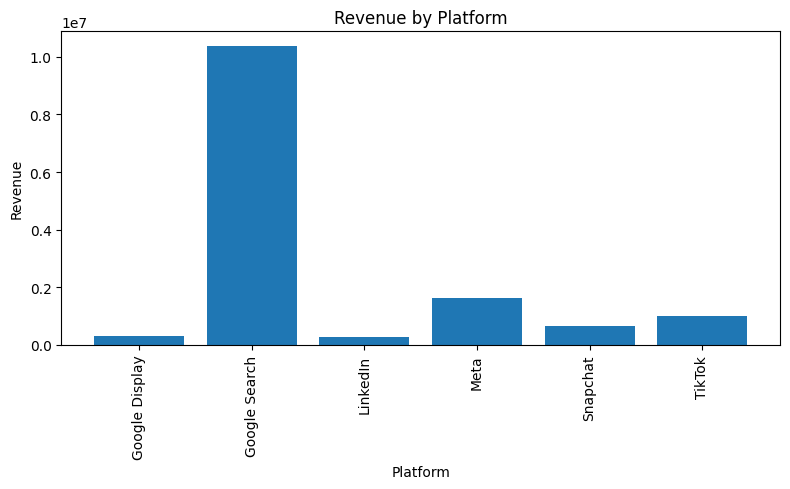

In [20]:
plt.figure(figsize=(8, 5))

plt.bar(
    platform_analysis['platform'],
    platform_analysis['revenue']
)

plt.title('Revenue by Platform')
plt.xlabel('Platform')
plt.ylabel('Revenue')
plt.xticks(rotation=(90))
plt.tight_layout()
plt.show()

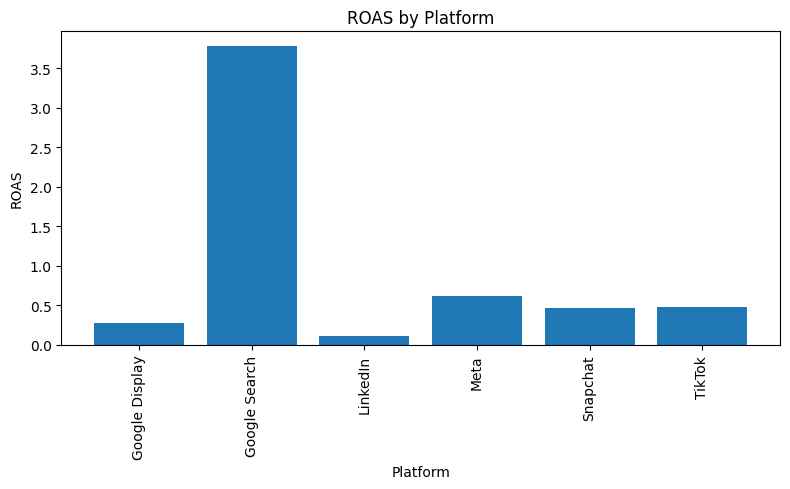

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(
    platform_analysis['platform'],
    platform_analysis['roas']
)

plt.title('ROAS by Platform')
plt.xlabel('Platform')
plt.ylabel('ROAS')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

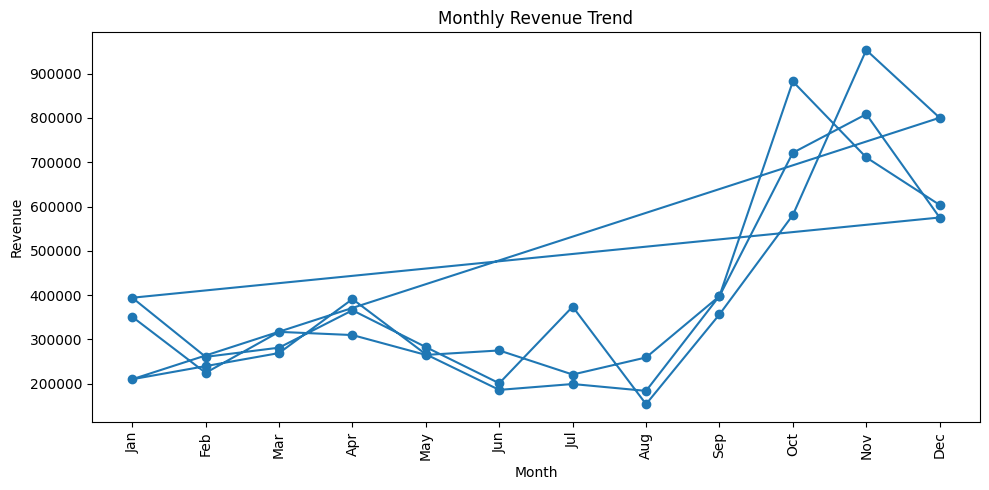

In [22]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_analysis['month_name'],
    monthly_analysis['revenue'],
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

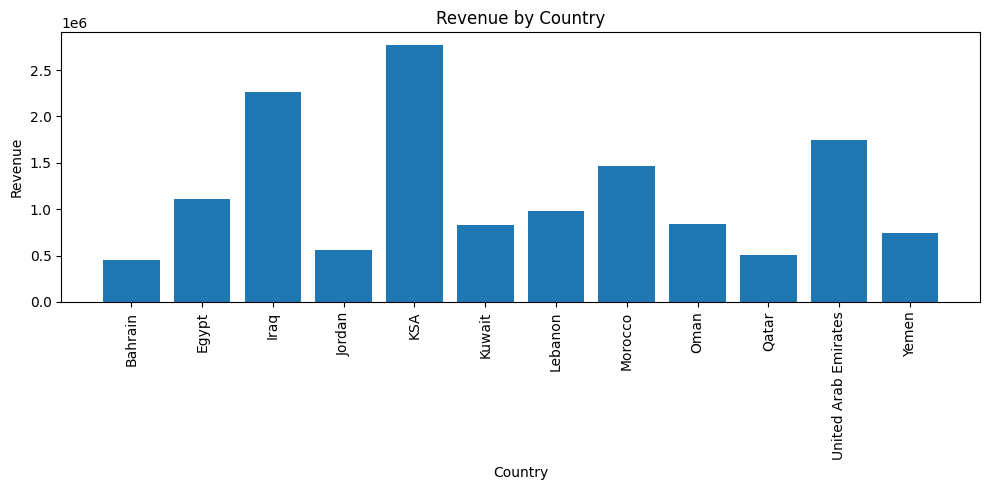

In [23]:
plt.figure(figsize=(10, 5))

plt.bar(
    country_analysis['country'],
    country_analysis['revenue']
)

plt.title('Revenue by Country')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

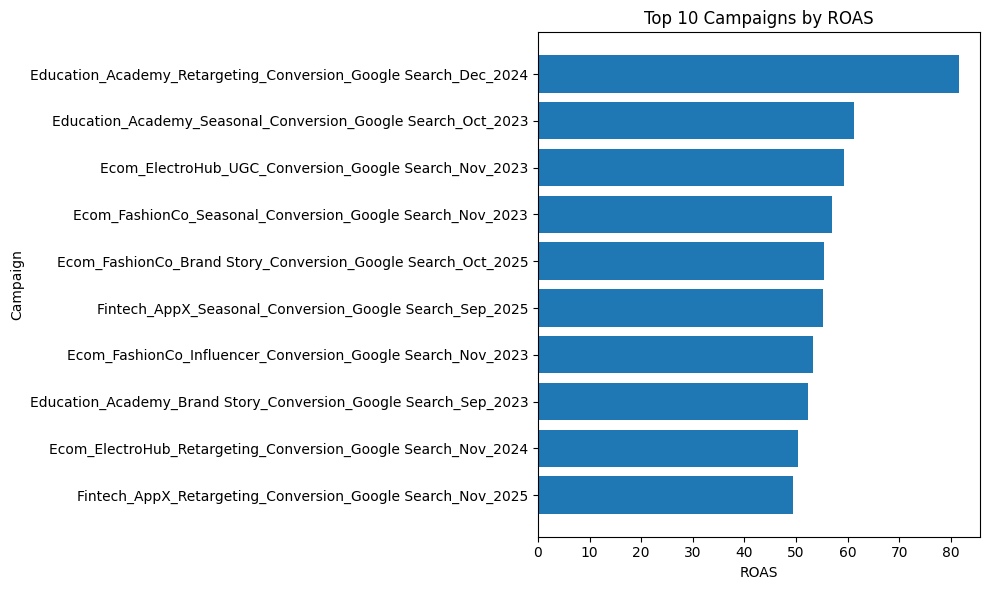

In [24]:
top_campaigns = campaign_analysis.sort_values(
    'roas',
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_campaigns['campaign_name'],
    top_campaigns['roas']
)

plt.title('Top 10 Campaigns by ROAS')
plt.xlabel('ROAS')
plt.ylabel('Campaign')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Key Business Insights

### 1. Google Search is the strongest-performing platform
- Google Search generated 10.36M revenue from 2.74M spend.
- ROAS: 3.78
- Conversion rate: 1.88%
- CPA: 12.66

### 2. Overall campaign efficiency is relatively low
- Overall ROAS: 1.13
- Overall conversion rate: 1.26%
- CPA: 39.15
- CTR: 1.51%

### 3. Campaign performance varies significantly
- The top campaigns showed substantially higher ROAS than the overall average.
- The highest listed campaign achieved a ROAS of 81.58.

### 4. Country performance varies
- Oman, Lebanon, and Kuwait showed relatively higher ROAS.
- Qatar showed the lowest ROAS among the listed countries.

### 5. Performance is stronger in some months
- Higher ROAS values were observed mainly during October–December.
- November 2024 recorded the highest monthly ROAS at 2.03.

### 6. Weekday performance differs
- Thursday generated the highest revenue at 2.29M.
- Sunday generated the lowest revenue at 1.61M.

### Summary
The analysis shows substantial variation in marketing performance across platforms, campaigns, countries, and time periods. Google Search delivered the strongest platform-level efficiency, while individual campaigns and markets showed significant differences in performance. These findings highlight opportunities for performance-based budget allocation, campaign optimization, and market-level monitoring.

## Business Recommendations

### 1. Prioritize high-performing platforms
- Google Search showed the strongest ROAS and conversion efficiency.
- Consider allocating more budget to high-performing Search campaigns while monitoring performance closely.

### 2. Optimize underperforming platforms
- Google Display, LinkedIn, Meta, Snapchat, and TikTok showed lower ROAS than Google Search.
- Review targeting, creative strategy, placements, and conversion performance before increasing their budgets.

### 3. Optimize campaigns based on efficiency
- Identify campaigns with strong ROAS and CPA and evaluate opportunities to scale them.
- Review low-performing campaigns for inefficient spending, weak targeting, or low conversion rates.

### 4. Use market-level budget allocation
- Country-level performance varies considerably.
- Consider allocating budget based on ROAS, CPA, and conversion rate rather than revenue alone.

### 5. Consider seasonal performance patterns
- Performance was generally stronger during several October–December periods.
- Plan seasonal campaigns and budgets around historically stronger periods while validating performance with new data.

### 6. Monitor performance continuously
- Track CTR, CPC, conversion rate, CPA, and ROAS regularly.
- Use these KPIs to identify performance changes and make data-driven optimization decisions.

### Overall Recommendation
A performance-based optimization strategy should focus on scaling efficient campaigns and platforms, reducing inefficient spending, and continuously evaluating performance across markets and time periods.

## Conclusion

This marketing campaign performance analysis examined campaign, platform, country, and time-based performance using key marketing KPIs such as CTR, CPC, conversion rate, CPA, and ROAS.

The analysis revealed significant differences in performance across platforms, campaigns, markets, and time periods. Google Search demonstrated strong conversion efficiency and ROAS, while several other platforms showed opportunities for optimization.

The findings also showed that campaign and country performance can vary considerably, highlighting the importance of performance-based budget allocation and continuous KPI monitoring.

Overall, this project demonstrates how Python and Pandas can be used to transform marketing data into actionable business insights and support data-driven marketing decisions.

## Final Notes

- The analysis covers campaign, platform, country, and time-based performance.
- Key KPIs include CTR, CPC, Conversion Rate, CPA, CPM, and ROAS.
- Insights and recommendations are based on the analyzed dataset.
- The dataset is simulated and is used for analytical and portfolio purposes.
- The notebook was reviewed for clarity, consistency, and reproducibility.